# 🇨🇴 Análisis de Generación Eléctrica — Colombia (API XM)
**Proyecto:** Energy Data Analysis Portfolio | **Versión:** 1.0  
**Autor:** Manuel Fernando Fajardo Rodríguez — Senior Electrical Engineer  
**Fuente de datos:** API pública de XM (Operador del Mercado Eléctrico de Colombia) via `pydataxm`

---

## 🎯 Objetivo

Construir un **pipeline ETL reproducible** que extrae datos de generación eléctrica por recurso desde la API de XM, los transforma en un modelo relacional limpio (listo para SQL o dashboards), y entrega un análisis exploratorio del parque generador colombiano.

**Preguntas que responde este notebook:**
1. ¿Cómo se distribuye la generación por tecnología (Solar, Hidráulica, Térmica, Eólica)?
2. ¿Cuál es el perfil horario típico de generación solar en Colombia?
3. ¿Qué tan concentrada está la capacidad generadora por agente del mercado?

---

## 📂 Estructura del Proyecto
```
xm-energia-colombia/
├── notebooks/
│   └── 01_ETL_exploracion_v1.ipynb   ← Estás aquí
├── data/
│   ├── raw/                           # Datos crudos descargados de la API
│   │   ├── datos_generacion_test.csv
│   │   ├── dim_plantas.csv
│   │   ├── dim_agentes.csv
│   │   └── dim_rios.csv
│   └── processed/                     # Outputs limpios del ETL
│       ├── fact_generacion.csv
│       └── generacion_enriquecida.csv
└── README.md
```

---

## 📋 Contexto del Mercado Eléctrico Colombiano

XM opera el **Sistema Interconectado Nacional (SIN)** y el mercado de energía mayorista de Colombia.  
La métrica `Gene` (Generación Real) reporta la energía producida en **kWh** por cada recurso generador, en bloques horarios (H1–H24) para cada día.  

**Tecnologías del parque generador:**
- 🌊 **Hidráulica (~65%)**: Aprovechamientos fluviales. Sensible al fenómeno de El Niño (aportes hídricos).
- ☀️ **Solar (~84% de los recursos, creciente en capacidad)**: Mayoritariamente GD (Generación Distribuida) y autogeneración.
- 🔥 **Térmica**: Gas, carbón, fuel oil. Rol de respaldo y precio de bolsa.
- 💨 **Eólica**: Proyectos en La Guajira (fase de expansión).

---
## ⚙️ Sección 0: Instalación y Carga de Librerías

In [1]:
# Instalación (solo necesaria una vez en entornos nuevos)
%pip install pydataxm pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
import os

# Intentamos importar pydataxm — si no está disponible, el notebook carga los CSVs de data/raw/
try:
    from pydataxm import pydataxm
    API_DISPONIBLE = True
    print("✅ pydataxm disponible — se puede conectar a la API en vivo.")
except ImportError:
    API_DISPONIBLE = False
    print("ℹ️  pydataxm no instalado — el notebook usará los archivos CSV de data/raw/.")

# Configuración global de visualizaciones
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# Rutas base del proyecto (ajusta si mueves el notebook)
BASE_DIR = os.path.join("..")  # raíz del proyecto desde notebooks/
RAW_DIR  = os.path.join(BASE_DIR, "data", "raw")
OUT_DIR  = os.path.join(BASE_DIR, "data", "processed")
os.makedirs(OUT_DIR, exist_ok=True)

print(f"\n📁 Directorio de salida: {os.path.abspath(OUT_DIR)}")

✅ pydataxm disponible — se puede conectar a la API en vivo.

📁 Directorio de salida: g:\My Drive\00_Archivos\Proyectos_Github\solar-generation-colombia-dash\data\processed


---
## 📥 Sección 1: Extracción de Datos (API XM)

La función `obtener_generacion` descarga la métrica **`Gene`** (Generación Real) desde la API de XM.
- Nivel: **`Recurso`** — una fila por planta generadora por día, con valores en cada una de las 24 horas.
- Límite de seguridad: máximo **31 días** por llamada para no sobrecargar la API.
- Manejo de errores: reintentos con `time.sleep` ante fallos de red.

In [3]:
import time

def obtener_generacion(fecha_inicio: dt.date, fecha_fin: dt.date) -> pd.DataFrame:
    """
    Descarga la generación real (métrica 'Gene') de todos los recursos del SIN
    desde la API de XM para el rango de fechas indicado.

    Args:
        fecha_inicio: Fecha de inicio (inclusive).
        fecha_fin:    Fecha de fin (inclusive). Máximo 31 días desde fecha_inicio.

    Returns:
        DataFrame con columnas: [Id, Values_code, Values_Hour01...Values_Hour24, Date]
        Retorna DataFrame vacío si la descarga falla.
    """
    MAX_DIAS = 31
    diferencia = (fecha_fin - fecha_inicio).days

    # Guard: ajuste automático si el rango excede el límite
    if diferencia > MAX_DIAS:
        print(f"⚠️  Rango de {diferencia} días supera el límite. Ajustando a {MAX_DIAS} días.")
        fecha_inicio = fecha_fin - dt.timedelta(days=MAX_DIAS)

    api_xm = pydataxm.ReadDB()
    rango   = pd.date_range(start=fecha_inicio, end=fecha_fin)
    bloques = []

    print(f"🔄 Descargando 'Gene' del {fecha_inicio} al {fecha_fin} ({len(rango)} días)...")

    for fecha in rango:
        f = fecha.date()
        for intento in range(3):  # Hasta 3 reintentos por día
            try:
                df_dia = api_xm.request_data("Gene", "Recurso", f, f)
                if df_dia is not None and not df_dia.empty:
                    bloques.append(df_dia)
                break  # Éxito — salir del loop de reintentos
            except Exception as e:
                if intento < 2:
                    time.sleep(2)
                else:
                    print(f"  ❌ Falló {f} tras 3 intentos: {e}")

    if not bloques:
        print("⚠️  No se obtuvieron datos. Retornando DataFrame vacío.")
        return pd.DataFrame()

    df_total = pd.concat(bloques, ignore_index=True)
    print(f"✅ Descarga completa — {df_total.shape[0]} filas, {df_total['Values_code'].nunique()} recursos únicos.")
    return df_total

In [ ]:
"""
─── MODOS DE OPERACIÓN ──────────────────────────────────────────────────────
Se puede trabajar entre 3 modos:

 MODO = "API"     Descarga los últimos 30 días (D-1) desde la API de XM.
                  Requiere: pydataxm instalado.

 MODO = "FIJO"    Descarga un rango de fechas específico desde la API.
                  Útil para analizar eventos históricos: El Niño,
                  racionamientos, expansión de renovables, etc.
                  Requiere: pydataxm instalado. Máximo 31 días por rango.
                  ⚠️  Para períodos > 31 días descarga por bloques y usa
                      pd.concat() para unirlos.

 MODO = "CSV"     Trabaja con los archivos de prueba del repositorio.
                  No requiere conexión ni credenciales. Ideal para desarrollo.

── Configuración exclusiva de MODO = "FIJO" ─────────────────────────────────

Referencia de períodos de interés del SIN colombiano:
  Niño 2023-2024 (bajo embalses)  → FECHA_INICIO_FIJO = dt.date(2024, 1, 1)
                                     FECHA_FIN_FIJO    = dt.date(2024, 1, 31)
  Expansión solar 2024            → FECHA_INICIO_FIJO = dt.date(2024, 6, 1)
                                     FECHA_FIN_FIJO    = dt.date(2024, 6, 30)
  Niño 2015-2016 (muy fuerte)     → FECHA_INICIO_FIJO = dt.date(2016, 1, 1)
                                     FECHA_FIN_FIJO    = dt.date(2016, 1, 31)

"""
MODO = "CSV"   # Opciones: "API" | "FIJO" | "CSV"


FECHA_INICIO_FIJO = dt.date(2026, 1, 1)
FECHA_FIN_FIJO    = dt.date(2026, 1, 31)
# ─────────────────────────────────────────────────────────────────────────────

if MODO == "API" and API_DISPONIBLE:
    # D-1: el mercado trabaja con el día anterior (hoy aún no está liquidado)
    fecha_fin    = dt.date.today() - dt.timedelta(days=1)
    fecha_inicio = fecha_fin - dt.timedelta(days=30)
    df_crudo = obtener_generacion(fecha_inicio, fecha_fin)

    if not df_crudo.empty:
        ts          = dt.datetime.now().strftime("%Y%m%d")
        ruta_salida = os.path.join(RAW_DIR, f"datos_generacion_{ts}.csv")
        df_crudo.to_csv(ruta_salida, index=False)
        print(f"💾 Datos guardados en: {ruta_salida}")

elif MODO == "FIJO" and API_DISPONIBLE:
    df_crudo = obtener_generacion(FECHA_INICIO_FIJO, FECHA_FIN_FIJO)

    if not df_crudo.empty:
        etiqueta    = f"{FECHA_INICIO_FIJO}_{FECHA_FIN_FIJO}"
        ruta_salida = os.path.join(RAW_DIR, f"datos_generacion_{etiqueta}.csv")
        df_crudo.to_csv(ruta_salida, index=False)
        print(f"💾 Datos guardados en: {ruta_salida}")

else:
    # Modo CSV: carga los datos de muestra incluidos en el repositorio
    ruta_csv = os.path.join(RAW_DIR, "datos_generacion_test.csv")
    df_crudo = pd.read_csv(ruta_csv)
    print(f"📂 Datos cargados desde CSV — {df_crudo.shape[0]:,} filas, "
          f"{df_crudo['Values_code'].nunique()} recursos únicos.")
    print(f"   Período: {df_crudo['Date'].min()} → {df_crudo['Date'].max()}")

df_crudo.head(3)

🔄 Descargando 'Gene' del 2026-03-13 al 2026-04-12 (31 días)...
✅ Descarga completa — 12989 filas, 490 recursos únicos.
💾 Datos guardados en: ..\data\raw\datos_generacion_20260413.csv


,Id,Values_code,Values_Hour01,Values_Hour02,Values_Hour03,Values_Hour04,Values_Hour05,Values_Hour06,Values_Hour07,Values_Hour08,...,Values_Hour16,Values_Hour17,Values_Hour18,Values_Hour19,Values_Hour20,Values_Hour21,Values_Hour22,Values_Hour23,Values_Hour24,Date
0,Recurso,2QBW,15799.50,15659.59,15518.99,15395.11,15307.62,15316.42,15879.27,15751.97,...,14386.94,14405.57,14328.14,14316.66,14209.79,14276.98,14079.61,13869.03,13911.07,2026-03-13
1,Recurso,2QEK,19766.27,19785.90,19772.82,19775.78,19758.56,19765.19,19774.06,19780.07,...,5001.35,5037.01,5015.71,5052.36,5002.92,5011.47,5014.20,5016.03,5040.18,2026-03-13
2,Recurso,2QRL,664.98,664.56,664.14,663.42,663.03,662.58,662.67,662.22,...,661.56,661.32,661.23,661.32,661.26,661.53,661.08,660.96,660.99,2026-03-13


---
## 📚 Sección 2: Carga de Catálogos Maestros (Dimensiones)

Los catálogos maestros son las **tablas de dimensión** del modelo relacional:
- `dim_plantas`: Información técnica de cada recurso generador (tecnología, fuente de energía, tipo de despacho, agente propietario).
- `dim_agentes`: Información de las empresas participantes del mercado.
- `dim_rios`: Cuencas hidrográficas asociadas a las plantas hidráulicas.

En el caso de que se arroje error, es necesario ejecutar la función `actualizar_catalogos_maestros()` (ver función auxiliar al final del notebook), con la cual se pueden actualizar también estos catálogos.

In [8]:
def cargar_catalogos(directorio: str) -> dict:
    """
    Carga los catálogos maestros desde el directorio indicado.
    Retorna un diccionario con los DataFrames crudos.
    """
    archivos = {
        "plantas":  "dim_plantas.csv",
        "agentes":  "dim_agentes.csv",
        "rios":     "dim_rios.csv",
    }
    catalogos = {}
    for nombre, archivo in archivos.items():
        ruta = os.path.join(directorio, archivo)
        df = pd.read_csv(ruta)
        catalogos[nombre] = df
        print(f"  ✅ {archivo:25s} → {df.shape[0]:>5} registros")
    return catalogos

print("📋 Cargando catálogos maestros...")
catalogos = cargar_catalogos(RAW_DIR)

📋 Cargando catálogos maestros...
  ✅ dim_plantas.csv           →  1598 registros
  ✅ dim_agentes.csv           →   690 registros
  ✅ dim_rios.csv              →    44 registros


In [9]:
# Vista rápida de la dimensión de plantas — las columnas más relevantes para el análisis
cols_relevantes = ['Values_Code', 'Values_Name', 'Values_Type', 'Values_EnerSource',
                   'Values_Disp', 'Values_RecType', 'Values_CompanyCode']
catalogos['plantas'][cols_relevantes].head(5)

,Values_Code,Values_Name,Values_Type,Values_EnerSource,Values_Disp,Values_RecType,Values_CompanyCode
0,2QBW,EL POPAL,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,NORMAL,ISGG
1,2QEK,SALTO II,HIDRAULICA,AGUA,DESPACHADO CENTRALMENTE,FILO DE AGUA,ENDG
2,2QRL,LA REBUSCA,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,GEN. DISTRIBUIDA,HZEG
3,2QV2,BAJO TULUA,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,NORMAL,EPSG
4,2R22,LAGUNETA,HIDRAULICA,AGUA,NO DESPACHADO CENTRALMENTE,NORMAL,ENDG


---
## 🔧 Sección 3: ETL — Transformación al Modelo Relacional

La API de XM entrega los datos en formato **wide** (una columna por hora: `Values_Hour01`...`Values_Hour24`).  
Para análisis y dashboards necesitamos formato **long** (una fila por hora), con los metadatos de cada planta.

**Pipeline ETL:**
```
datos_crudos (wide)  →  melt()  →  fact_generacion (long)  →  merge(dim_plantas)  →  generacion_enriquecida
```

**Resultado esperado:** tabla con columnas `[Fecha, Hora, Codigo_Planta, Nombre_Planta, Tecnologia, Fuente_Energia, Codigo_Agente, Generacion_kWh]`

In [10]:
def transformar_generacion(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Convierte los datos de generación del formato wide (24 columnas de horas)
    al formato long (una fila por planta por hora por día).

    Args:
        df_raw: DataFrame crudo tal como llega de la API o del CSV.
                Columnas esperadas: ['Date', 'Values_code', 'Values_Hour01'...'Values_Hour24']

    Returns:
        DataFrame en formato long con columnas: ['Fecha', 'Hora', 'Codigo_Planta', 'Generacion_kWh']
    """
    # Identificar las 24 columnas horarias
    cols_hora = [c for c in df_raw.columns if c.startswith("Values_Hour")]
    assert len(cols_hora) == 24, f"Se esperaban 24 columnas horarias, se encontraron {len(cols_hora)}."

    # PASO 1 — Se usa pd.melt para colapsar las columnas de horas en filas
    df_long = pd.melt(
        df_raw,
        id_vars=["Date", "Values_code"],   # Columnas fijas (identificadores)
        value_vars=cols_hora,               # Las 24 columnas que se colapsan en filas
        var_name="Hora_Cruda",
        value_name="Generacion_kWh"
    )

    # PASO 2 — Extraer el número de la hora limpio (ej. 'Values_Hour03' → 3)
    df_long["Hora"] = df_long["Hora_Cruda"].str.replace("Values_Hour", "", regex=False).astype(int)

    # PASO 3 — Renombrar columnas a nombres semánticos claros
    df_long = df_long.rename(columns={"Date": "Fecha", "Values_code": "Codigo_Planta"})

    # PASO 4 — Eliminar columna auxiliar y ordenar
    df_long = (df_long
               .drop(columns=["Hora_Cruda"])
               .sort_values(["Fecha", "Codigo_Planta", "Hora"])
               .reset_index(drop=True))

    # PASO 5 — Tipado correcto
    df_long["Fecha"]          = pd.to_datetime(df_long["Fecha"])
    df_long["Generacion_kWh"] = df_long["Generacion_kWh"].astype(float)

    return df_long[["Fecha", "Hora", "Codigo_Planta", "Generacion_kWh"]]


def preparar_dim_plantas(df_dim: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia y renombra la dimensión de plantas para facilitar los JOINs y el análisis.

    Args:
        df_dim: DataFrame crudo de dim_plantas.csv

    Returns:
        DataFrame limpio con columnas renombradas y sin columnas auxiliares de la API.
    """
    mapa_columnas = {
        "Values_Code":         "Codigo_Planta",
        "Values_Name":         "Nombre_Planta",
        "Values_Type":         "Tecnologia",
        "Values_EnerSource":   "Fuente_Energia",
        "Values_CompanyCode":  "Codigo_Agente",
        "Values_Disp":         "Tipo_Despacho",
        "Values_RecType":      "Tipo_Recurso",
        "Values_OperStartdate":"Fecha_Inicio_Op",
        "Values_State":        "Estado",
    }
    return (df_dim
            .rename(columns=mapa_columnas)
            .drop(columns=["Id", "Date"], errors="ignore")
            [list(mapa_columnas.values())])  # Reordenar columnas

In [11]:
print("🔧 Ejecutando ETL...")

# ── Paso A: Transformar datos de generación ──
fact_gen = transformar_generacion(df_crudo)
print(f"  ✅ fact_generacion:  {fact_gen.shape[0]:>7,} filas × {fact_gen.shape[1]} columnas")
fact_gen.head()

🔧 Ejecutando ETL...
  ✅ fact_generacion:  311,736 filas × 4 columnas


,Fecha,Hora,Codigo_Planta,Generacion_kWh
0,2026-03-13,1,2QBW,15799.50
1,2026-03-13,2,2QBW,15659.59
2,2026-03-13,3,2QBW,15518.99
3,2026-03-13,4,2QBW,15395.11
4,2026-03-13,5,2QBW,15307.62


In [12]:
# ── Paso B: Preparar dimensión de plantas ──
dim_plantas = preparar_dim_plantas(catalogos["plantas"])
print(f"  ✅ dim_plantas:      {dim_plantas.shape[0]:>7,} plantas en el SIN")
dim_plantas.head()

  ✅ dim_plantas:        1,598 plantas en el SIN


,Codigo_Planta,Nombre_Planta,Tecnologia,Fuente_Energia,Codigo_Agente,Tipo_Despacho,Tipo_Recurso,Fecha_Inicio_Op,Estado
0,2QBW,EL POPAL,HIDRAULICA,AGUA,ISGG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-03-31,OPERACION
1,2QEK,SALTO II,HIDRAULICA,AGUA,ENDG,DESPACHADO CENTRALMENTE,FILO DE AGUA,2014-06-25,OPERACION
2,2QRL,LA REBUSCA,HIDRAULICA,AGUA,HZEG,NO DESPACHADO CENTRALMENTE,GEN. DISTRIBUIDA,2014-07-24,OPERACION
3,2QV2,BAJO TULUA,HIDRAULICA,AGUA,EPSG,NO DESPACHADO CENTRALMENTE,NORMAL,2015-01-30,OPERACION
4,2R22,LAGUNETA,HIDRAULICA,AGUA,ENDG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-12-17,OPERACION


In [13]:
# ── Paso C: JOIN — enriquecer la tabla de hechos con metadatos de planta ──
gen_enriquecida = pd.merge(
    fact_gen,
    dim_plantas,
    on="Codigo_Planta",
    how="inner"  # Solo plantas presentes en ambas tablas
)
print(f"  ✅ gen_enriquecida:  {gen_enriquecida.shape[0]:>7,} filas × {gen_enriquecida.shape[1]} columnas")
gen_enriquecida.head()

  ✅ gen_enriquecida:  311,736 filas × 12 columnas


,Fecha,Hora,Codigo_Planta,Generacion_kWh,Nombre_Planta,Tecnologia,Fuente_Energia,Codigo_Agente,Tipo_Despacho,Tipo_Recurso,Fecha_Inicio_Op,Estado
0,2026-03-13,1,2QBW,15799.50,EL POPAL,HIDRAULICA,AGUA,ISGG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-03-31,OPERACION
1,2026-03-13,2,2QBW,15659.59,EL POPAL,HIDRAULICA,AGUA,ISGG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-03-31,OPERACION
2,2026-03-13,3,2QBW,15518.99,EL POPAL,HIDRAULICA,AGUA,ISGG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-03-31,OPERACION
3,2026-03-13,4,2QBW,15395.11,EL POPAL,HIDRAULICA,AGUA,ISGG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-03-31,OPERACION
4,2026-03-13,5,2QBW,15307.62,EL POPAL,HIDRAULICA,AGUA,ISGG,NO DESPACHADO CENTRALMENTE,NORMAL,2014-03-31,OPERACION


In [14]:
# Verificación de integridad: no deben quedar plantas sin cruzar
plantas_sin_match = set(fact_gen['Codigo_Planta']) - set(dim_plantas['Codigo_Planta'])
if plantas_sin_match:
    print(f"  ⚠️  {len(plantas_sin_match)} plantas en generación sin match en catálogo: {plantas_sin_match}")
else:
    print(f"  ✅ Integridad OK — todas las plantas tienen match en dim_plantas.")

print("\n✅ ETL completado.")

  ✅ Integridad OK — todas las plantas tienen match en dim_plantas.

✅ ETL completado.


In [15]:
# Vista previa del modelo relacional final
cols_preview = ["Fecha", "Hora", "Codigo_Planta", "Nombre_Planta", "Tecnologia", "Fuente_Energia", "Generacion_kWh"]
gen_enriquecida[cols_preview].head(8)

,Fecha,Hora,Codigo_Planta,Nombre_Planta,Tecnologia,Fuente_Energia,Generacion_kWh
0,2026-03-13,1,2QBW,EL POPAL,HIDRAULICA,AGUA,15799.50
1,2026-03-13,2,2QBW,EL POPAL,HIDRAULICA,AGUA,15659.59
2,2026-03-13,3,2QBW,EL POPAL,HIDRAULICA,AGUA,15518.99
3,2026-03-13,4,2QBW,EL POPAL,HIDRAULICA,AGUA,15395.11
4,2026-03-13,5,2QBW,EL POPAL,HIDRAULICA,AGUA,15307.62
5,2026-03-13,6,2QBW,EL POPAL,HIDRAULICA,AGUA,15316.42
6,2026-03-13,7,2QBW,EL POPAL,HIDRAULICA,AGUA,15879.27
7,2026-03-13,8,2QBW,EL POPAL,HIDRAULICA,AGUA,15751.97


In [16]:
# Guardar outputs limpios para uso en notebooks posteriores y dashboard
fact_gen.to_csv(os.path.join(OUT_DIR, "fact_generacion.csv"), index=False)
gen_enriquecida.to_csv(os.path.join(OUT_DIR, "generacion_enriquecida.csv"), index=False)
dim_plantas.to_csv(os.path.join(OUT_DIR, "dim_plantas_clean.csv"), index=False)
print("💾 Archivos guardados en data/processed/:")
print("   • fact_generacion.csv")
print("   • generacion_enriquecida.csv")
print("   • dim_plantas_clean.csv")

💾 Archivos guardados en data/processed/:
   • fact_generacion.csv
   • generacion_enriquecida.csv
   • dim_plantas_clean.csv


---
## 📊 Sección 4: Análisis Exploratorio (EDA)

Con el modelo relacional limpio, respondemos las preguntas clave del negocio.

### 4.1 Distribución de la Generación por Tecnología

Colombia tiene una matriz energética diversa, liderada históricamente por **generación hidroeléctrica**.  
La energía solar, aunque dominante en número de recursos, es aún incipiente en términos de energía total generada (GD y autogeneración de pequeña escala).

In [17]:
# Aggregation: generación total y número de plantas por tecnología
resumen_tecnologia = (
    gen_enriquecida
    .groupby("Tecnologia")
    .agg(
        Generacion_Total_MWh=("Generacion_kWh", lambda x: x.sum() / 1000),  # kWh → MWh
        Num_Recursos=("Codigo_Planta", "nunique"),
    )
    .sort_values("Generacion_Total_MWh", ascending=False)
    .reset_index()
)
resumen_tecnologia["Participacion_%"] = (
    resumen_tecnologia["Generacion_Total_MWh"] / resumen_tecnologia["Generacion_Total_MWh"].sum() * 100
).round(1)

print("Generación por Tecnología:")
print(resumen_tecnologia.to_string(index=False))

Generación por Tecnología:
 Tecnologia  Generacion_Total_MWh  Num_Recursos  Participacion_%
 HIDRAULICA          5.228257e+06           143             75.8
    TERMICA          1.002403e+06            53             14.5
      SOLAR          5.827547e+05           279              8.4
COGENERADOR          7.486905e+04            12              1.1
     EOLICA          1.079747e+04             3              0.2


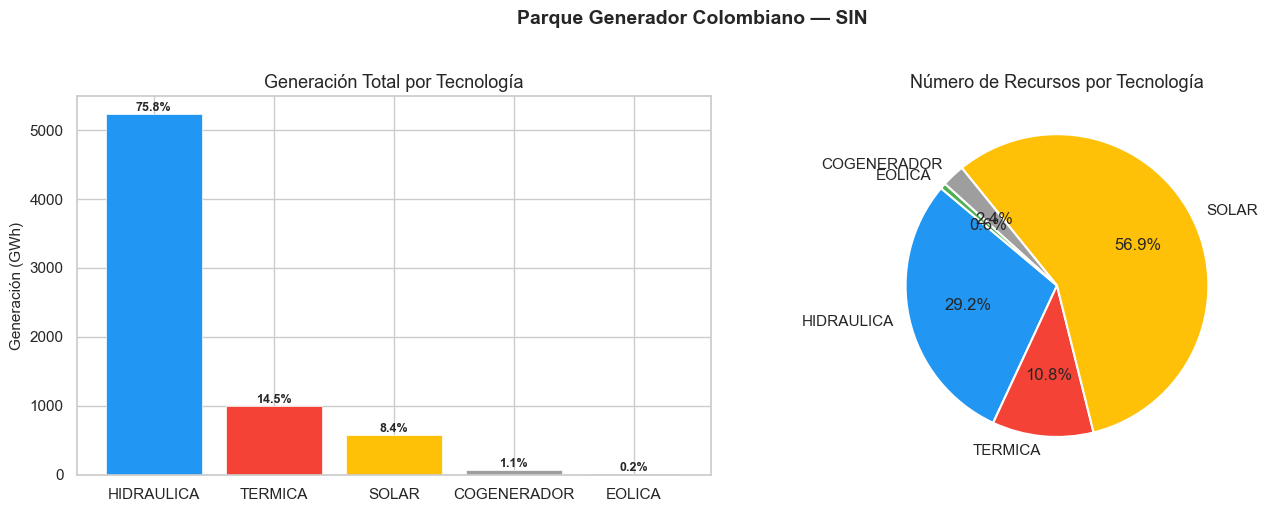

💡 Insight: A pesar de que la SOLAR representa ~56% de los recursos del SIN,
   se evidencia que el uso de energía HIDRÍCA re presenta un 76% de la generación. Esto refleja que la mayoría de
   los recursos solares son pequeñas instalaciones de GD y autogeneración.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Barras de generación total ──
colores = {"HIDRAULICA": "#2196F3", "SOLAR": "#FFC107", "TERMICA": "#F44336",
           "EOLICA": "#4CAF50", "COGENERADOR": "#9E9E9E"}
bar_colors = [colores.get(t, "#9E9E9E") for t in resumen_tecnologia["Tecnologia"]]

bars = axes[0].bar(
    resumen_tecnologia["Tecnologia"],
    resumen_tecnologia["Generacion_Total_MWh"] / 1e3,  # → GWh
    color=bar_colors, edgecolor="white", linewidth=0.5
)
for bar, pct in zip(bars, resumen_tecnologia["Participacion_%"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"{pct}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_title("Generación Total por Tecnología")
axes[0].set_ylabel("Generación (GWh)")
axes[0].set_xlabel("")

# ── Gráfico 2: Pie de número de recursos ──
pie_colors = [colores.get(t, "#9E9E9E") for t in resumen_tecnologia["Tecnologia"]]
axes[1].pie(
    resumen_tecnologia["Num_Recursos"],
    labels=resumen_tecnologia["Tecnologia"],
    autopct="%1.1f%%",
    colors=pie_colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
axes[1].set_title("Número de Recursos por Tecnología")

fig.suptitle("Parque Generador Colombiano — SIN", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig01_generacion_por_tecnologia.png"), dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: A pesar de que la SOLAR representa ~56% de los recursos del SIN,")
print("   se evidencia que el uso de energía HIDRÍCA re presenta un 76% de la generación. Esto refleja que la mayoría de")
print("   los recursos solares son pequeñas instalaciones de GD y autogeneración.")

### 4.2 Perfil Horario de Generación Solar

La **curva de generación solar** tiene forma de campana (bell curve): cero durante la noche, pico al mediodía, cero al anochecer. En Colombia, con irradiancia horizontal global (GHI) superior a 4.5 kWh/m²/día en promedio, el perfil solar es muy pronunciado.

Este perfil tiene implicaciones para la operación del sistema: la **complementariedad solar-hidráulica** es clave para la seguridad energética.

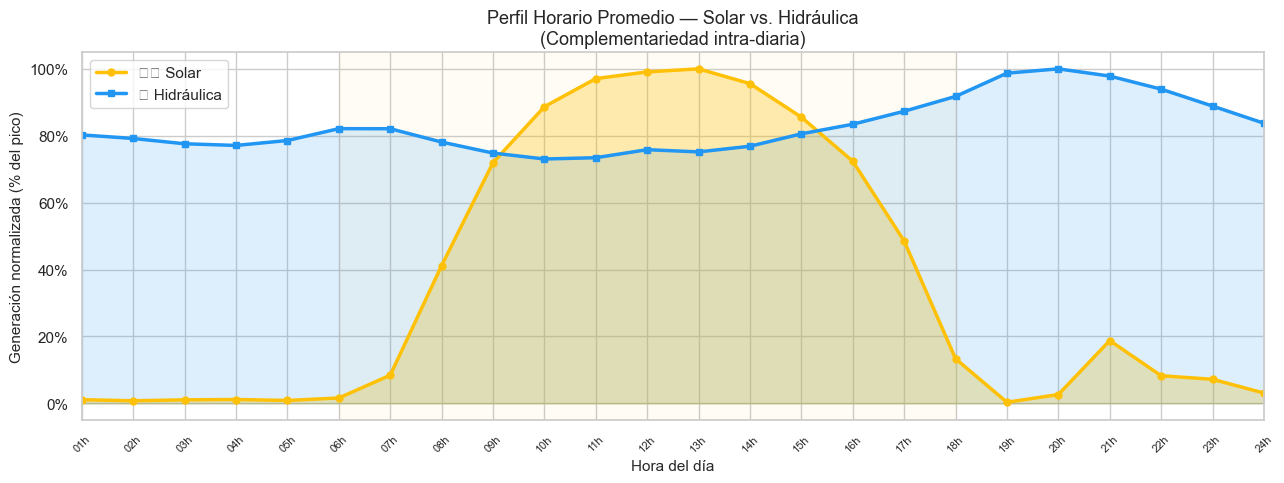

💡 Insight: El perfil solar tiene su pico entre las 09h-15h. La hidroeléctrica
   muestra mayor generación en horas pico de demanda (18h-22h), confirmando
   la complementariedad Solar + Hidráulica que hace tan valiosa la solar en Colombia.


In [21]:
# Filtrar solo recursos solares y calcular perfil horario promedio
gen_solar = gen_enriquecida[gen_enriquecida["Tecnologia"] == "SOLAR"].copy()
gen_hidro = gen_enriquecida[gen_enriquecida["Tecnologia"] == "HIDRAULICA"].copy()

perfil_solar = gen_solar.groupby("Hora")["Generacion_kWh"].mean().reset_index()
perfil_hidro = gen_hidro.groupby("Hora")["Generacion_kWh"].mean().reset_index()

# Normalizar a porcentaje del pico para comparar perfiles en la misma escala
perfil_solar["Gen_Norm_%"] = perfil_solar["Generacion_kWh"] / perfil_solar["Generacion_kWh"].max() * 100
perfil_hidro["Gen_Norm_%"] = perfil_hidro["Generacion_kWh"] / perfil_hidro["Generacion_kWh"].max() * 100

fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(perfil_solar["Hora"], perfil_solar["Gen_Norm_%"],
                alpha=0.3, color="#FFC107", label="_nolegend_")
ax.plot(perfil_solar["Hora"], perfil_solar["Gen_Norm_%"],
        color="#FFC107", lw=2.5, marker="o", ms=5, label="☀️ Solar")

ax.fill_between(perfil_hidro["Hora"], perfil_hidro["Gen_Norm_%"],
                alpha=0.15, color="#2196F3", label="_nolegend_")
ax.plot(perfil_hidro["Hora"], perfil_hidro["Gen_Norm_%"],
        color="#2196F3", lw=2.5, marker="s", ms=5, label="💧 Hidráulica")

ax.axvspan(6, 18, alpha=0.04, color="#FFC107")  # Franja horaria solar
ax.set_xlim(1, 24)
ax.set_xticks(range(1, 25))
ax.set_xticklabels([f"{h:02d}h" for h in range(1, 25)], rotation=45, fontsize=8)
ax.set_xlabel("Hora del día")
ax.set_ylabel("Generación normalizada (% del pico)")
ax.set_title("Perfil Horario Promedio — Solar vs. Hidráulica\n(Complementariedad intra-diaria)")
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig02_perfil_horario_solar_hidro.png"), dpi=150, bbox_inches="tight")
plt.show()
print("💡 Insight: El perfil solar tiene su pico entre las 09h-15h. La hidroeléctrica")
print("   muestra mayor generación en horas pico de demanda (18h-22h), confirmando")
print("   la complementariedad Solar + Hidráulica que hace tan valiosa la solar en Colombia.")

### 4.3 Concentración del Mercado por Agente

Uno de los indicadores de competitividad del mercado eléctrico es el grado de concentración de la generación.  
Aquí calculamos la contribución de los **top agentes generadores** para identificar si el mercado está dominado por pocos actores.

In [24]:
gen_enriquecida.columns

Index(['Fecha', 'Hora', 'Codigo_Planta', 'Generacion_kWh', 'Nombre_Planta',
       'Tecnologia', 'Fuente_Energia', 'Codigo_Agente', 'Tipo_Despacho',
       'Tipo_Recurso', 'Fecha_Inicio_Op', 'Estado'],
      dtype='object')

In [23]:
# Generación total por agente
gen_por_agente = (
    gen_enriquecida
    .groupby(["Codigo_Agente", "Tecnologia"])["Generacion_kWh"]
    .sum()
    .div(1e6)  # kWh → GWh (más legible)
    .reset_index()
    .rename(columns={"Generacion_kWh": "Generacion_GWh"})
)

gen_por_agente.head()

,Codigo_Agente,Tecnologia,Generacion_GWh
0,AAGG,SOLAR,14.439252
1,ABAG,HIDRAULICA,7.306545
2,ADCG,HIDRAULICA,4.761019
3,BCCG,SOLAR,1.450480
4,BCCG,TERMICA,0.005901


In [25]:
# Top 15 agentes por generación total (todas las tecnologías)
top_agentes = (
    gen_por_agente
    .groupby("Codigo_Agente")["Generacion_GWh"]
    .sum()
    .nlargest(15)
    .reset_index()
)

top_agentes.head()

,Codigo_Agente,Generacion_GWh
0,EPMG,2012.244756
1,ISGG,1420.199592
2,ENDG,1248.314340
3,EPSG,442.253890
4,GECG,273.987781


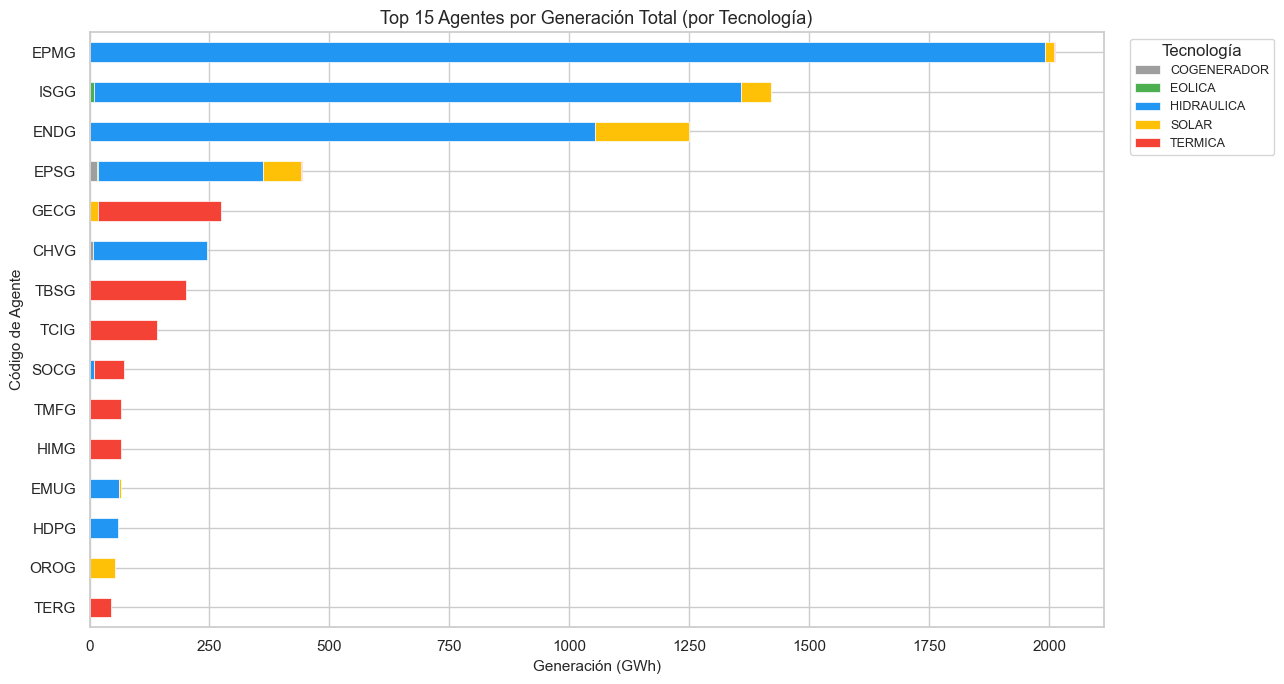

In [26]:
# Filtrar datos del gráfico apilado
gen_top_apilado = gen_por_agente[gen_por_agente["Codigo_Agente"].isin(top_agentes["Codigo_Agente"])]
tabla_pivot = gen_top_apilado.pivot_table(
    index="Codigo_Agente", columns="Tecnologia", values="Generacion_GWh", aggfunc="sum", fill_value=0
).reindex(top_agentes["Codigo_Agente"])

# Gráfico de barras apiladas
ax = tabla_pivot.plot(
    kind="barh",
    stacked=True,
    color=[colores.get(c, "#9E9E9E") for c in tabla_pivot.columns],
    figsize=(13, 7),
    edgecolor="white",
    linewidth=0.5
)

ax.set_xlabel("Generación (GWh)")
ax.set_ylabel("Código de Agente")
ax.set_title("Top 15 Agentes por Generación Total (por Tecnología)")
ax.legend(title="Tecnología", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.invert_yaxis()  # Mayor generador arriba
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig03_top_agentes_generacion.png"), dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Desglose por Tipo de Recurso (RecType)

La columna `Tipo_Recurso` clasifica de forma más granular que `Tecnologia` lo cual hace que se pueda visualizar de mejor forma la **estructura real del parque generador colombiano**, especialmente en las FNCER:

| RecType | Descripción |
|---------|-------------|
| `AUTOG PEQ. ESCALA` | Autogeneradores de pequeña escala (< 1 MW, CREG 174-2021) |
| `GEN. DISTRIBUIDA`  | Generación Distribuida conectada a redes de distribución |
| `AUTOGENERADOR`     | Grandes autogeneradores industriales (> 1 MW) |
| `NORMAL`            | Plantas despachadas centralmente por XM |
| `FILO DE AGUA`      | Pequeñas centrales hidroeléctricas sin embalse |
| `CICLO COMBINADO`   | Termoeléctricas de alta eficiencia |
| `COGENERADOR`       | Co-generación (calor + electricidad) |

**¿Por qué es importante esta consideración?**  
Teniendo en cuenta que se presentan variados tipos de unidades de generación el sector eléctrico colombiano clasificadas por las resoluciones CREG como la`AUTOG PEQ. ESCALA` y `GEN. DISTRIBUIDA`, las cuales son fundamentalmente distintas a las plantas catalogadas como`NORMAL` en términos de regulación (CREG), despacho y remuneración.

In [ ]:
# ── Generación por Tipo de Recurso (todas las tecnologías) ──────────────────
resumen_rectype = (
    gen_enriquecida
    .groupby(["Tecnologia", "Tipo_Recurso"])
    .agg(
        Generacion_GWh=("Generacion_kWh", lambda x: x.sum() / 1e6),
        Num_Recursos=("Codigo_Planta", "nunique"),
    )
    .reset_index()
    .sort_values(["Tecnologia", "Generacion_GWh"], ascending=[True, False])
)

print("Generación y recursos por Tecnología + Tipo de Recurso:")
print(resumen_rectype.to_string(index=False))

---
## 🗓️ Sección 5: Evolución Diaria de la Generación

Aunque el período de muestra es corto (3 días), este análisis establece la base para la versión v2, donde se trabajará con series de tiempo de 30+ días para detectar tendencias y anomalías.

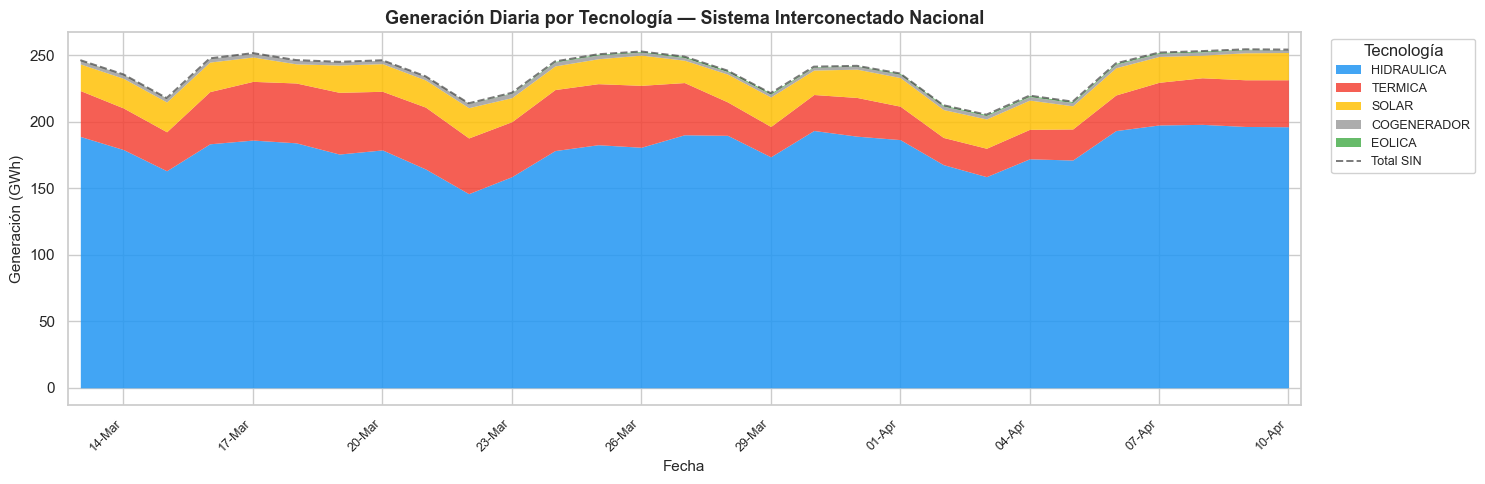

In [28]:
import matplotlib.dates as mdates

gen_diaria = (
    gen_enriquecida
    .groupby(["Fecha", "Tecnologia"])["Generacion_kWh"]
    .sum()
    .div(1e6)  # kWh → GWh
    .reset_index()
    .rename(columns={"Generacion_kWh": "Generacion_GWh"})
)

# Ordenar tecnologías de mayor a menor aporte para el apilado
orden_tec = (gen_diaria.groupby("Tecnologia")["Generacion_GWh"]
             .sum().sort_values(ascending=False).index.tolist())

# Pivot con índice datetime real (necesario para mdates)
tabla_diaria = (gen_diaria
                .pivot_table(index="Fecha", columns="Tecnologia",
                             values="Generacion_GWh", aggfunc="sum")
                .fillna(0)
                .reindex(columns=orden_tec))
tabla_diaria.index = pd.to_datetime(tabla_diaria.index)

# ── Gráfico: área apilada ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))

tecnologias_plot = tabla_diaria.columns.tolist()
colores_plot     = [colores.get(t, "#9E9E9E") for t in tecnologias_plot]

# Acumular manualmente para el fill_between apilado
acum = pd.Series(0.0, index=tabla_diaria.index)
for tec, color in zip(tecnologias_plot, colores_plot):
    ax.fill_between(tabla_diaria.index,
                    acum.values, (acum + tabla_diaria[tec]).values,
                    label=tec, color=color, alpha=0.85, linewidth=0)
    acum = acum + tabla_diaria[tec]

# Línea del total del sistema
ax.plot(tabla_diaria.index, acum.values, color="#333333",
        linewidth=1.4, linestyle="--", label="Total SIN", alpha=0.65)

# ── Eje X adaptativo: intervalo según duración del período ───────────────────
n_dias = (tabla_diaria.index[-1] - tabla_diaria.index[0]).days

if n_dias <= 10:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
elif n_dias <= 31:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
elif n_dias <= 90:
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))  # Lunes
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
else:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)

ax.set_title("Generación Diaria por Tecnología — Sistema Interconectado Nacional",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generación (GWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title="Tecnología", bbox_to_anchor=(1.02, 1),
          loc="upper left", fontsize=9, framealpha=0.9)
ax.margins(x=0.01)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fig04_generacion_diaria.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## 📋 Sección 6: Resumen y Próximos Pasos

### Resultados de esta versión (v1)
- ✅ Pipeline ETL funcional y reproducible: extracción desde la API XM (con el uso de pydataxm) → modelo relacional limpio.
- ✅ Modelo relacional: `fact_generacion` + `dim_plantas` + `dim_agentes` + `dim_rios`.
- ✅ EDA inicial: distribución por tecnología, perfil horario solar, concentración de mercado.
- ✅ Archivos limpios exportados en `data/processed/` listos para dashboards.

### Roadmap del proyecto

| Versión | Descripción |
|---------|-------------|
| **v1** (actual) | ETL + EDA básico sobre datos de muestra |
| **v2** | Serie de tiempo 30+ días · Análisis de complementariedad Solar-Hidro · Heatmaps mensuales |
| **v3** | Incorporar `Aportes Hídricos` + `Emisiones CO2` + `Precio de Bolsa` (contexto ESG) |
| **v4** | Dashboard interactivo en Streamlit desplegado en Streamlit Community Cloud |
| **v5** | Modelo predictivo: predicción de generación solar (Proyecto 2 del portafolio) |

---
## 🔧 Anexo: Función para Actualizar Catálogos Maestros

In [7]:
def actualizar_catalogos_maestros(directorio_salida: str, catalogos: dict = None) -> None:
    """
    Descarga y guarda los catálogos maestros del SIN desde la API de XM.
    Útil para mantener las dimensiones actualizadas en pipelines de producción.

    Args:
        directorio_salida: Directorio donde guardar los CSV.
        catalogos: Diccionario {metrica_api: nombre_archivo.csv}.
                   Si es None, usa los tres catálogos estándar.
    """
    if not API_DISPONIBLE:
        print("⚠️  pydataxm no instalado. Instala con: pip install pydataxm")
        return

    if catalogos is None:
        catalogos = {
            "ListadoRecursos": "dim_plantas.csv",
            "ListadoAgentes":  "dim_agentes.csv",
            "ListadoRios":     "dim_rios.csv",
        }

    api_xm      = pydataxm.ReadDB()
    fecha_foto  = dt.date.today() - dt.timedelta(days=1)  # Foto del día anterior

    print(f"📋 Descargando catálogos maestros al {fecha_foto}...")
    os.makedirs(directorio_salida, exist_ok=True)

    for metrica, nombre_archivo in catalogos.items():
        try:
            df = api_xm.request_data(metrica, "Sistema", fecha_foto, fecha_foto)
            if df is not None and not df.empty:
                ruta = os.path.join(directorio_salida, nombre_archivo)
                df.to_csv(ruta, index=False)
                print(f"  ✅ {nombre_archivo:25s} → {df.shape[0]} registros")
            else:
                print(f"  ⚠️  {metrica}: respuesta vacía")
        except Exception as e:
            print(f"  ❌ {metrica}: {e}")

    print("\n✅ Catálogos actualizados.")

# Para actualizar, descomenta la siguiente línea:
actualizar_catalogos_maestros(RAW_DIR)

📋 Descargando catálogos maestros al 2026-04-12...
  ✅ dim_plantas.csv           → 1598 registros
  ✅ dim_agentes.csv           → 690 registros
  ✅ dim_rios.csv              → 44 registros

✅ Catálogos actualizados.
